# 03 · Subidas de precio y bajadas a la mitad: lo que decide Finora frente a lo que hace el cliente

**Pregunta.** Cuando el monto de un cliente cambia entre dos meses pagados, ¿fue el cliente (más uso, otro plan, cancelación) o fue
Finora (precio, descuento)? El CFO pregunta exactamente eso: cuánto del cambio del MRR es cliente y cuánto pricing o descuentos.

**Qué salió de aquí:**

- Hay un patrón repetido **L → L(1 + k·p) → L(1 + p)**: la primera factura tras una subida de precio cobra **k meses retroactivos** de la
  diferencia y luego el monto se estabiliza en +p. El alza estable es **+8,25 % (2022), +5,45 % (2023) y +3,93 % (2024)** y llega en olas
  (abr–may 2023, jun–oct 2024). El modelo actual lo lee como expansión grande + contracción al mes siguiente.
- Hay **307 episodios** en 260 clientes donde el monto cae **exactamente a la mitad**. Solo 13 vuelven al monto anterior; 84 terminan en 0 y
  106 siguen a la mitad al final. **Con caja no se puede saber si fue un descuento o un downgrade.**

De aquí salen las decisiones **D2** (las subidas de precio van en su propia línea y el retroactivo es un cargo único) y **D3** (MRR en
dos capas: lista − descuento = neto; el fin de un descuento no es expansión).

In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.dates as mdates
import matplotlib.pyplot as plt

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
DATA = ROOT / "data"
MM = 1e6

pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 40)
pd.set_option("display.max_colwidth", 120)

VIZ = ["#009786", "#8670c0", "#ba673f", "#2b88c0", "#b4608a", "#a28218"]
INK, MUTED, LINE = "#11151A", "#50585B", "#E3E7EC"
plt.rcParams.update({
    "figure.figsize": (9, 3.8), "figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
    "axes.edgecolor": LINE, "axes.labelcolor": MUTED, "xtick.color": MUTED, "ytick.color": MUTED,
    "axes.titlecolor": INK, "axes.titlelocation": "left", "axes.titleweight": "bold", "axes.grid": True,
    "grid.color": LINE, "grid.linewidth": 0.6, "axes.axisbelow": True, "legend.frameon": False, "font.size": 10,
})


def cifras_publicadas() -> dict:
    """Cifras de app/data/key_figures.csv (las que citan README, HALLAZGOS y NOTA_CORTA) como números."""
    d = pd.read_csv(ROOT / "app" / "data" / "key_figures.csv", dtype=str, keep_default_na=False)
    out = {}
    for k, v in zip(d["cifra"], d["valor"]):
        try:
            out[k] = float(v.replace(".", "").replace(",", ".").replace("−", "-"))
        except ValueError:
            out[k] = v
    return out


KF = cifras_publicadas()


def eje_fechas(*axes):
    """Marcas anuales en los ejes de tiempo."""
    for ax in axes:
        ax.xaxis.set_major_locator(mdates.YearLocator())
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
        ax.xaxis.set_minor_locator(mdates.MonthLocator(bymonth=(4, 7, 10)))

In [2]:
tx = pd.read_csv(DATA / "Transactions.csv", encoding="utf-8-sig").rename(columns={"ID": "cliente"})
tx["month"] = pd.to_datetime(tx["month"], format="%m/%d/%Y").dt.to_period("M")
tx = tx.sort_values(["cliente", "month"]).reset_index(drop=True)
print(f"{tx['cliente'].nunique()} clientes × {tx['month'].nunique()} meses = {len(tx):,} filas")

1961 clientes × 34 meses = 66,674 filas


## 1. Qué tipo de cambios hay entre dos meses pagados consecutivos

In [3]:
g = tx.groupby("cliente")["amount"]
tx["prev"], tx["next"] = g.shift(), g.shift(-1)
c = tx[(tx["amount"] > 0) & (tx["prev"] > 0)].copy()
c["ratio"] = c["amount"] / c["prev"]
c["tipo"] = np.select(
    [np.isclose(c["ratio"], 1), np.isclose(c["ratio"], 0.5, atol=0.005), np.isclose(c["ratio"], 2.0, atol=0.01),
     c["ratio"].between(1.02, 1.12), c["ratio"].between(0.9, 0.98)],
    ["igual", "× 0,5", "× 2", "+2 % a +12 %", "−2 % a −10 %"], default="otro")
tab = pd.crosstab(c["month"].dt.year, c["tipo"])[["igual", "+2 % a +12 %", "−2 % a −10 %", "× 0,5", "× 2", "otro"]]
tab["total"] = tab.sum(axis=1)
tab

tipo,igual,+2 % a +12 %,−2 % a −10 %,"× 0,5",× 2,otro,total
month,,,,,,,
2022,5247,26,16,137,68,279,5773
2023,9846,234,65,74,35,461,10715
2024,12914,381,199,100,32,428,14054


**Lectura.** Tres familias de cambio concentran casi todo lo que no es "igual": alzas pequeñas de +2 % a +12 % (que crecen
cada año), bajadas pequeñas de −2 % a −10 % (que aparecen en 2024, justo el mes después de un alza con retroactivo) y saltos exactos
× 0,5 y × 2. Cada familia tiene una explicación distinta.

## 2. Subidas de precio con cobro retroactivo: el patrón 1 + k·p

In [4]:
r = tx[(tx["prev"] > 0) & (tx["amount"] > 0) & (tx["next"] > 0) & (tx["amount"] > tx["next"]) & (tx["next"] > tx["prev"])].copy()
r["p"] = r["next"] / r["prev"] - 1
r = r[r["p"].between(0.01, 0.15)]
r["k"] = (r["amount"] / r["prev"] - 1) / r["p"]
r["k_ent"] = r["k"].round()
retro = r[r["k_ent"].between(2, 6) & ((r["k"] - r["k_ent"]).abs() < 0.05)]
print("eventos con el patrón L → L(1 + k·p) → L(1 + p):", len(retro))
print("k (meses retroactivos cobrados):", retro["k_ent"].astype(int).value_counts().to_dict())
print("alza estable p, mediana por año (%):", (retro.groupby(retro["month"].dt.year)["p"].median() * 100).round(2).to_dict())
ej = retro[retro["k_ent"] == 4].iloc[0]
print(f"\nEjemplo (anonimizado): {ej['prev']:g} → {ej['amount']:.3f} (+{(ej['amount'] / ej['prev'] - 1) * 100:.1f} % = 4 × {ej['p'] * 100:.2f} %)"
      f" → {ej['next']:.3f} (+{ej['p'] * 100:.2f} %) y se queda ahí")

eventos con el patrón L → L(1 + k·p) → L(1 + p): 246
k (meses retroactivos cobrados): {2: 165, 4: 45, 3: 30, 5: 5, 6: 1}
alza estable p, mediana por año (%): {2022: 8.25, 2023: 5.45, 2024: 3.93}

Ejemplo (anonimizado): 4.2 → 5.116 (+21.8 % = 4 × 5.45 %) → 4.429 (+5.45 %) y se queda ahí


alzas de +2 % a +12 % por año: {2022: 26, 2023: 234, 2024: 381}
meses desde el primer pago, módulo 12 (si fuera por aniversario se concentraría en 0): {0: 60, 1: 29, 2: 11, 3: 36, 4: 50, 5: 27, 6: 29, 7: 58, 8: 71, 9: 126, 10: 66, 11: 78}


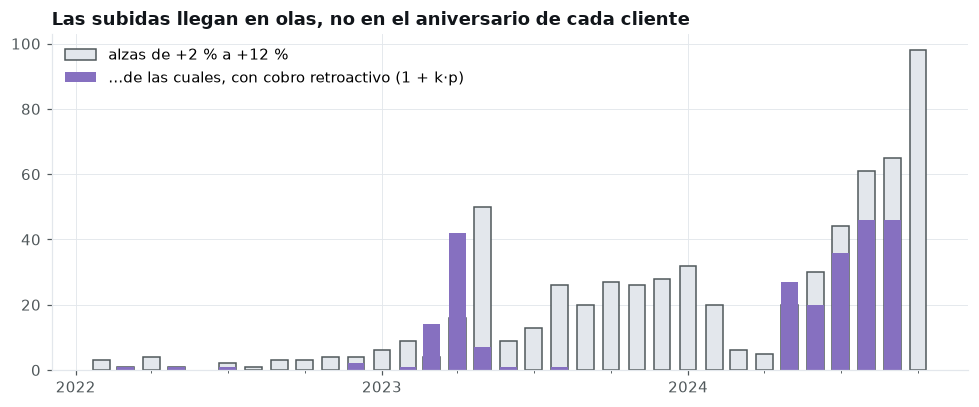

In [5]:
inc = c[c["tipo"] == "+2 % a +12 %"]
por_mes = pd.DataFrame({"alzas": inc.groupby("month").size(), "con retroactivo": retro.groupby("month").size()}).fillna(0)
print("alzas de +2 % a +12 % por año:", inc.groupby(inc["month"].dt.year).size().to_dict())
primer = tx[tx["amount"] > 0].groupby("cliente")["month"].min()
desde = (inc["month"] - inc["cliente"].map(primer)).apply(lambda d: d.n) % 12
print("meses desde el primer pago, módulo 12 (si fuera por aniversario se concentraría en 0):", desde.value_counts().sort_index().to_dict())

fig, ax = plt.subplots()
x = por_mes.index.to_timestamp()
ax.bar(x, por_mes["alzas"], width=20, color=LINE, edgecolor=MUTED, label="alzas de +2 % a +12 %")
ax.bar(x, por_mes["con retroactivo"], width=20, color=VIZ[1], label="…de las cuales, con cobro retroactivo (1 + k·p)")
ax.set_title("Las subidas llegan en olas, no en el aniversario de cada cliente"); ax.legend(loc="upper left"); eje_fechas(ax); plt.tight_layout()

**Lectura.** Las alzas se concentran en meses concretos para todos los clientes a la vez y no dependen de la antigüedad:
son **decisiones de pricing de Finora**, no comportamiento del cliente. En el modelo actual cada una genera una "expansión" de +11 % a
+22 % seguida de una "contracción" al mes siguiente, y el neto parece crecimiento del cliente.

**Decisión D2.** La subida va en su **propia línea** del puente (`price_uplift`), separada de la expansión. El retroactivo es un
**cargo único** y sale del MRR. Confianza **alta** si aparece el patrón 1 + k·p; **media** si es un alza de +2 % a +10 % que se mantiene
al mes siguiente; las del último mes quedan **en confirmación**. Nos apartamos a propósito de la convención de ChartMogul (que
clasifica por dirección del cambio) porque la pregunta del CFO exige separar quién decidió el cambio.

## 3. Bajadas exactas a la mitad: ¿descuento o downgrade?

episodios de bajada exacta a la mitad: 307 | clientes: 260
duración a la mitad (meses) – mediana: 6 | p90: 21


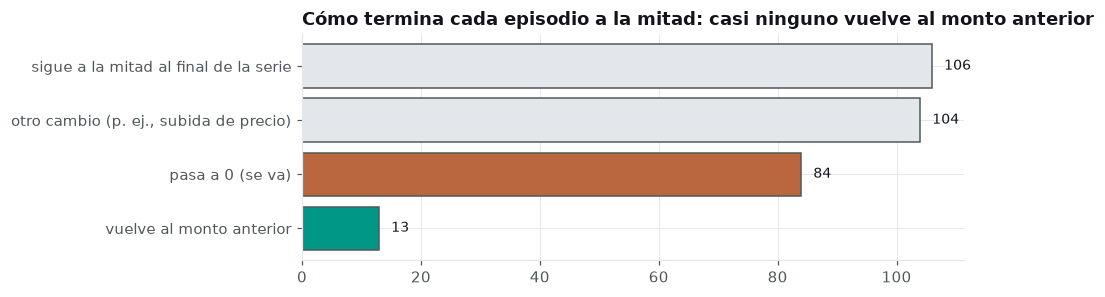

In [6]:
episodios = []
for cid, g in tx.groupby("cliente"):
    a, meses = g["amount"].to_numpy(), g["month"].to_numpy()
    i = 1
    while i < len(a):
        if a[i - 1] > 0 and a[i] > 0 and np.isclose(a[i] / a[i - 1], 0.5):
            base, j = a[i - 1], i
            while j < len(a) and a[j] > 0 and np.isclose(a[j], a[i]):
                j += 1
            fin = ("vuelve al monto anterior" if j < len(a) and a[j] > 0 and np.isclose(a[j], base)
                   else "pasa a 0 (se va)" if j < len(a) and a[j] == 0
                   else "otro cambio (p. ej., subida de precio)" if j < len(a)
                   else "sigue a la mitad al final de la serie")
            episodios.append((cid, str(meses[i]), j - i, fin, base))
            i = j
        else:
            i += 1
ep = pd.DataFrame(episodios, columns=["cliente", "inicio", "meses_a_mitad", "como_termina", "monto_base"])
print(f"episodios de bajada exacta a la mitad: {len(ep)} | clientes: {ep['cliente'].nunique()}")
print("duración a la mitad (meses) – mediana:", int(ep["meses_a_mitad"].median()), "| p90:", int(ep["meses_a_mitad"].quantile(0.9)))
fin = ep["como_termina"].value_counts()

fig, ax = plt.subplots(figsize=(9, 2.8))
ax.barh(fin.index[::-1], fin.values[::-1], color=[VIZ[0] if "vuelve" in k else VIZ[2] if "0" in k else LINE for k in fin.index[::-1]],
        edgecolor=MUTED)
for y, v in enumerate(fin.values[::-1]):
    ax.text(v + 2, y, str(v), va="center", fontsize=9, color=INK)
ax.set_title("Cómo termina cada episodio a la mitad: casi ninguno vuelve al monto anterior"); plt.tight_layout()

In [7]:
intro = 0
for cid, g in tx.groupby("cliente"):
    a = g["amount"].to_numpy()
    k = int(np.argmax(a > 0)); j = k
    while j < len(a) and a[j] > 0 and np.isclose(a[j], a[k]):
        j += 1
    if j < len(a) and a[j] > 0 and np.isclose(a[j] / a[k], 2.0):
        intro += 1
print("clientes cuyo primer bloque de pagos se duplica exactamente después (¿precio introductorio?):", intro)

clientes cuyo primer bloque de pagos se duplica exactamente después (¿precio introductorio?): 69


**Lectura.** Si las bajadas a la mitad fueran descuentos temporales, se esperaría que muchas volvieran al monto anterior: solo
13 de 307 lo hacen. Si fueran downgrades, no se esperaría que 69 clientes **empiecen** a la mitad y luego dupliquen (eso parece
un precio de bienvenida). Las dos lecturas conviven y **con caja no se pueden separar**. Es literalmente la pregunta del CFO,
demostrada con sus propios datos.

## Conclusión: decisión D3 y lo que no se puede concluir

- **No se puede** decir cuánto del cambio del MRR son descuentos: no hay precio de lista ni registro de descuentos.
- En el modelo corregido estas bajadas se clasifican como **contracción marcada como ambigua** (85 eventos en la ventana, −4,2 MM) y
  se calcula una **cota superior ilustrativa** de revenue no capturado si todas fueran descuentos que se mantuvieron (40,8 MM;
  notebook 04). No es una estimación: es el argumento para medir en dos capas.
- **Propuesta:** MRR en dos capas, **lista − descuento = neto**, con el descuento como entidad con inicio, fin, motivo y aprobador.
  El inicio y el fin de un descuento se clasifican en la capa de pricing: **el fin de un descuento no es expansión**.